# NER Model From Scratch
Train a simple BiLSTM tagger on OntoNotes 5 NER. Saves per-epoch weights in Streamlit and metrics plots in Images.

In [1]:
import json
import os
from collections import Counter
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

DATASET_DIR = os.path.join("..", "Dataset")
IMAGES_DIR = os.path.join("..", "Images")
STREAMLIT_DIR = os.path.join("..", "Streamlit")
os.makedirs(IMAGES_DIR, exist_ok=True)
os.makedirs(STREAMLIT_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

## Data and paths
Set paths, output folders, and random seeds.

In [2]:
label_path = os.path.join(DATASET_DIR, "label.json")
with open(label_path, "r", encoding="utf-8") as f:
    label_to_id = json.load(f)
    id_to_label = {v: k for k, v in label_to_id.items()}

train_files = sorted(glob(os.path.join(DATASET_DIR, "train*.json")))
valid_file = os.path.join(DATASET_DIR, "valid.json")
test_file = os.path.join(DATASET_DIR, "test.json")

def load_records(paths):
    records = []
    for path in paths:
        if not os.path.exists(path):
            continue
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                records.append(json.loads(line))
    return records

train_records = load_records(train_files)
valid_records = load_records([valid_file])
test_records = load_records([test_file])

len(train_records), len(valid_records), len(test_records)

(59924, 8528, 8262)

## Load datasets
Read OntoNotes 5 JSONL files and split into train, validation, and test.

In [3]:
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

token_counter = Counter()
for r in train_records:
    token_counter.update(r["tokens"])

vocab = [PAD_TOKEN, UNK_TOKEN] + [t for t, _ in token_counter.most_common()]
token_to_id = {t: i for i, t in enumerate(vocab)}

pad_id = token_to_id[PAD_TOKEN]
unk_id = token_to_id[UNK_TOKEN]
num_labels = len(label_to_id)

def encode_record(record):
    tokens = record["tokens"]
    tags = record["tags"]
    token_ids = [token_to_id.get(t, unk_id) for t in tokens]
    tag_ids = tags
    return token_ids, tag_ids

def pad_batch(batch):
    max_len = max(len(x[0]) for x in batch)
    token_batch = []
    tag_batch = []
    mask_batch = []
    for token_ids, tag_ids in batch:
        pad_len = max_len - len(token_ids)
        token_batch.append(token_ids + [pad_id] * pad_len)
        tag_batch.append(tag_ids + [-100] * pad_len)
        mask_batch.append([1] * len(token_ids) + [0] * pad_len)
    return (
        torch.tensor(token_batch, dtype=torch.long),
        torch.tensor(tag_batch, dtype=torch.long),
        torch.tensor(mask_batch, dtype=torch.float32),
    )

class NERDataset(Dataset):
    def __init__(self, records):
        self.records = records
    def __len__(self):
        return len(self.records)
    def __getitem__(self, idx):
        return encode_record(self.records[idx])

train_ds = NERDataset(train_records)
valid_ds = NERDataset(valid_records)
test_ds = NERDataset(test_records)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, collate_fn=pad_batch)
valid_loader = DataLoader(valid_ds, batch_size=64, shuffle=False, collate_fn=pad_batch)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, collate_fn=pad_batch)

len(vocab), num_labels

(41326, 37)

## Vocabulary and batching
Build token vocabulary, encode samples, and create padded batches.

In [4]:
class BiLSTMTagger(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_labels, pad_id):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(0.2)
        self.classifier = nn.Linear(hidden_dim * 2, num_labels)

    def forward(self, input_ids, mask):
        x = self.embedding(input_ids)
        x, _ = self.lstm(x)
        x = self.dropout(x)
        logits = self.classifier(x)
        return logits

model = BiLSTMTagger(
    vocab_size=len(vocab),
    embed_dim=128,
    hidden_dim=256,
    num_labels=num_labels,
    pad_id=pad_id,
).to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=-100)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

## Model
Define a BiLSTM tagger and optimizer.

In [5]:
def run_epoch(model, loader, train=False):
    total_loss = 0.0
    total_correct = 0
    total_tokens = 0
    model.train(train)
    for input_ids, tag_ids, mask in loader:
        input_ids = input_ids.to(DEVICE)
        tag_ids = tag_ids.to(DEVICE)
        mask = mask.to(DEVICE)

        logits = model(input_ids, mask)
        loss = criterion(logits.view(-1, num_labels), tag_ids.view(-1))

        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss += loss.item()
        with torch.no_grad():
            preds = logits.argmax(-1)
            valid = tag_ids != -100
            total_correct += (preds[valid] == tag_ids[valid]).sum().item()
            total_tokens += valid.sum().item()
    avg_loss = total_loss / max(len(loader), 1)
    accuracy = total_correct / max(total_tokens, 1)
    return avg_loss, accuracy

num_epochs = 5
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = run_epoch(model, train_loader, train=True)
    val_loss, val_acc = run_epoch(model, valid_loader, train=False)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:02d} | train loss {train_loss:.4f} acc {train_acc:.4f} | val loss {val_loss:.4f} acc {val_acc:.4f}")

Epoch 01 | train loss 0.3595 acc 0.9184 | val loss 0.2092 acc 0.9425
Epoch 02 | train loss 0.1501 acc 0.9602 | val loss 0.1669 acc 0.9542
Epoch 03 | train loss 0.0962 acc 0.9733 | val loss 0.1614 acc 0.9557
Epoch 04 | train loss 0.0646 acc 0.9814 | val loss 0.1596 acc 0.9575
Epoch 05 | train loss 0.0431 acc 0.9874 | val loss 0.1725 acc 0.9566


In [6]:
weight_path = os.path.join(STREAMLIT_DIR, f"ner_model.pt")
torch.save(model.state_dict(), weight_path)

## Training
Run epochs, track loss and accuracy, and save weights per epoch.

Test loss 0.1632 | Test acc 0.9602
Saved: ../Images/ner_training_metrics.png


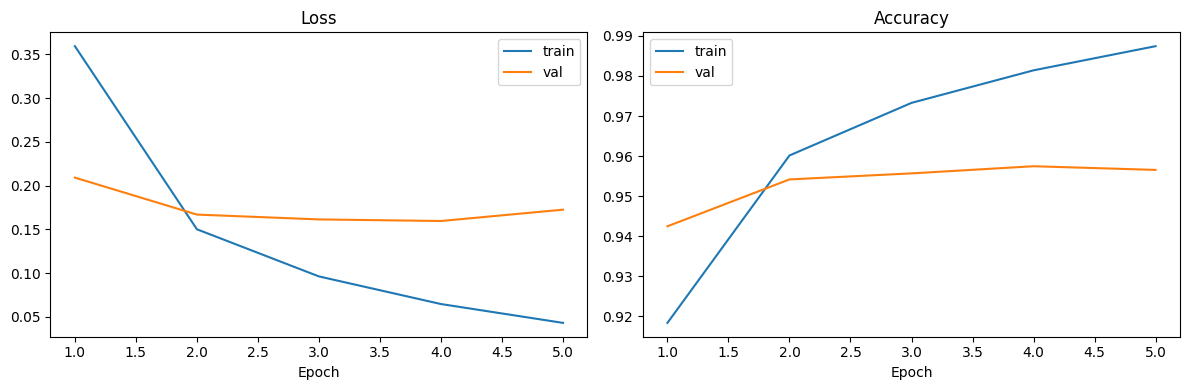

Saved: ../Images/ner_final_metrics.png


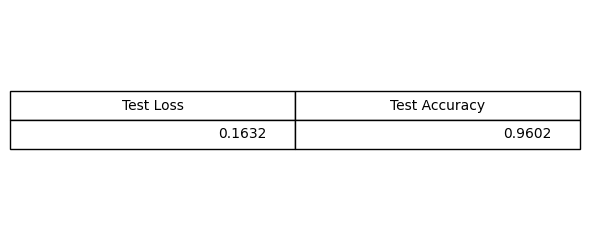

In [7]:
test_loss, test_acc = run_epoch(model, test_loader, train=False)
print(f"Test loss {test_loss:.4f} | Test acc {test_acc:.4f}")

epochs = np.arange(1, num_epochs + 1)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(epochs, history["train_loss"], label="train")
ax[0].plot(epochs, history["val_loss"], label="val")
ax[0].set_title("Loss")
ax[0].set_xlabel("Epoch")
ax[0].legend()

ax[1].plot(epochs, history["train_acc"], label="train")
ax[1].plot(epochs, history["val_acc"], label="val")
ax[1].set_title("Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].legend()

metrics_path = os.path.join(IMAGES_DIR, "ner_training_metrics.png")
fig.tight_layout()
fig.savefig(metrics_path, dpi=150)
print(f"Saved: {metrics_path}")
plt.show()

# Final metrics summary image
fig, ax = plt.subplots(figsize=(6, 2.5))
ax.axis("off")
table = ax.table(
    cellText=[[f"{test_loss:.4f}", f"{test_acc:.4f}"]],
    colLabels=["Test Loss", "Test Accuracy"],
    loc="center",
)
table.scale(1, 1.5)
summary_path = os.path.join(IMAGES_DIR, "ner_final_metrics.png")
fig.tight_layout()
fig.savefig(summary_path, dpi=150)
print(f"Saved: {summary_path}")
plt.show()